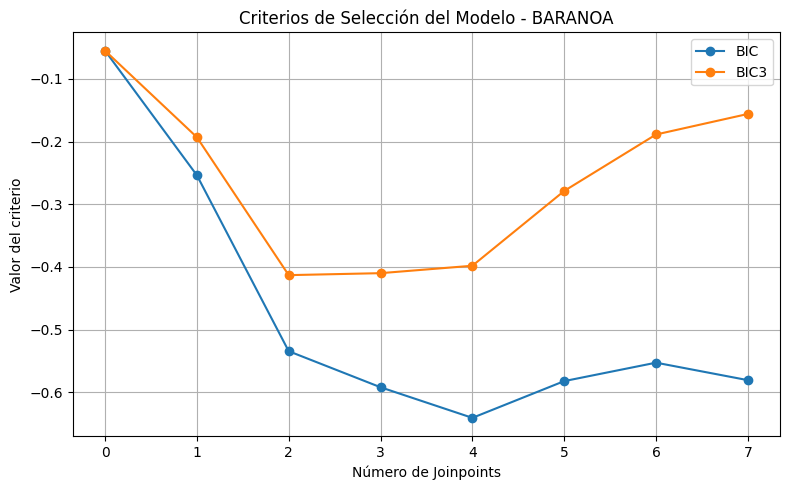

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Cargar archivo ===
# Cambia la ruta por la ubicación real de tu archivo
ruta = r"C:\Dengue_caracterization\DATA_LAST\JoinPoint Results\Total.Export.Model.Selection.txt"
df = pd.read_csv(ruta)

# === 2. Seleccionar municipio ===
municipio = "BARANOA"     # <-- cámbialo por el que quieras analizar

df_muni = df[df["municipio"] == municipio].copy()

# Convertir columnas numéricas si vienen con espacios
for col in ["BIC", "BIC3", "WBIC"]:
    df_muni[col] = pd.to_numeric(df_muni[col], errors="coerce")

# === 3. Ordenar por número de joinpoints ===
df_muni = df_muni.sort_values("# Joinpoints")

# === 4. Gráfica ===
plt.figure(figsize=(8, 5))

plt.plot(df_muni["# Joinpoints"], df_muni["BIC"], marker="o", label="BIC")
plt.plot(df_muni["# Joinpoints"], df_muni["BIC3"], marker="o", label="BIC3")

plt.xlabel("Número de Joinpoints")
plt.ylabel("Valor del criterio")
plt.title(f"Criterios de Selección del Modelo - {municipio}")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


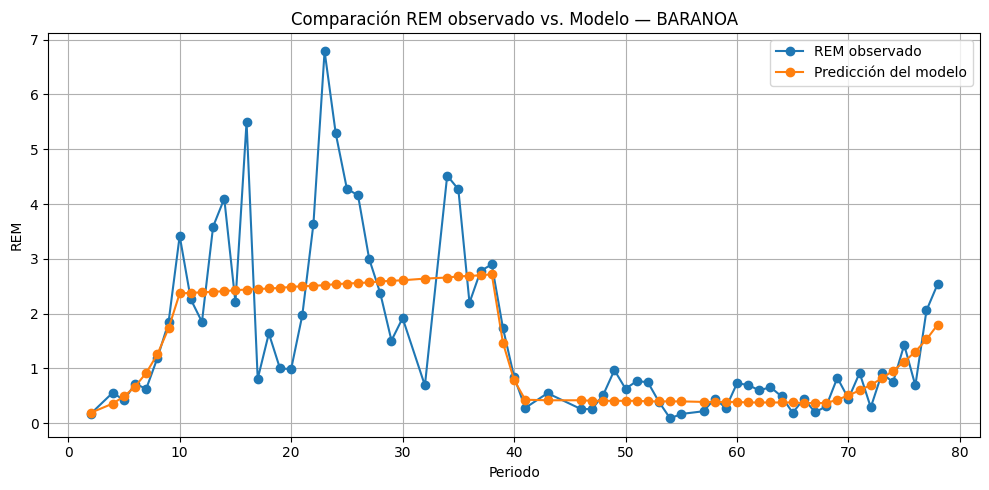

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Cargar archivo ===
# Cambia la ruta al archivo correcto
df = pd.read_csv(r"C:\Dengue_caracterization\DATA_LAST\JoinPoint Results\Total.Export.Data.txt")

# === 2. Seleccionar municipio ===
municipio = "BARANOA"   # <-- cámbialo según necesites
df_muni = df[df["municipio"] == municipio].copy()

# === 3. Ordenar por periodo ===
df_muni = df_muni.sort_values("periodo_global")

# === 4. Crear la gráfica ===
plt.figure(figsize=(10,5))

# Serie original
plt.plot(
    df_muni["periodo_global"],
    df_muni["REM"],
    marker="o",
    label="REM observado"
)

# Serie ajustada del modelo Joinpoint
plt.plot(
    df_muni["periodo_global"],
    df_muni["Model"],
    marker="o",
    label="Predicción del modelo"
)

plt.xlabel("Periodo")
plt.ylabel("REM")
plt.title(f"Comparación REM observado vs. Modelo — {municipio}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


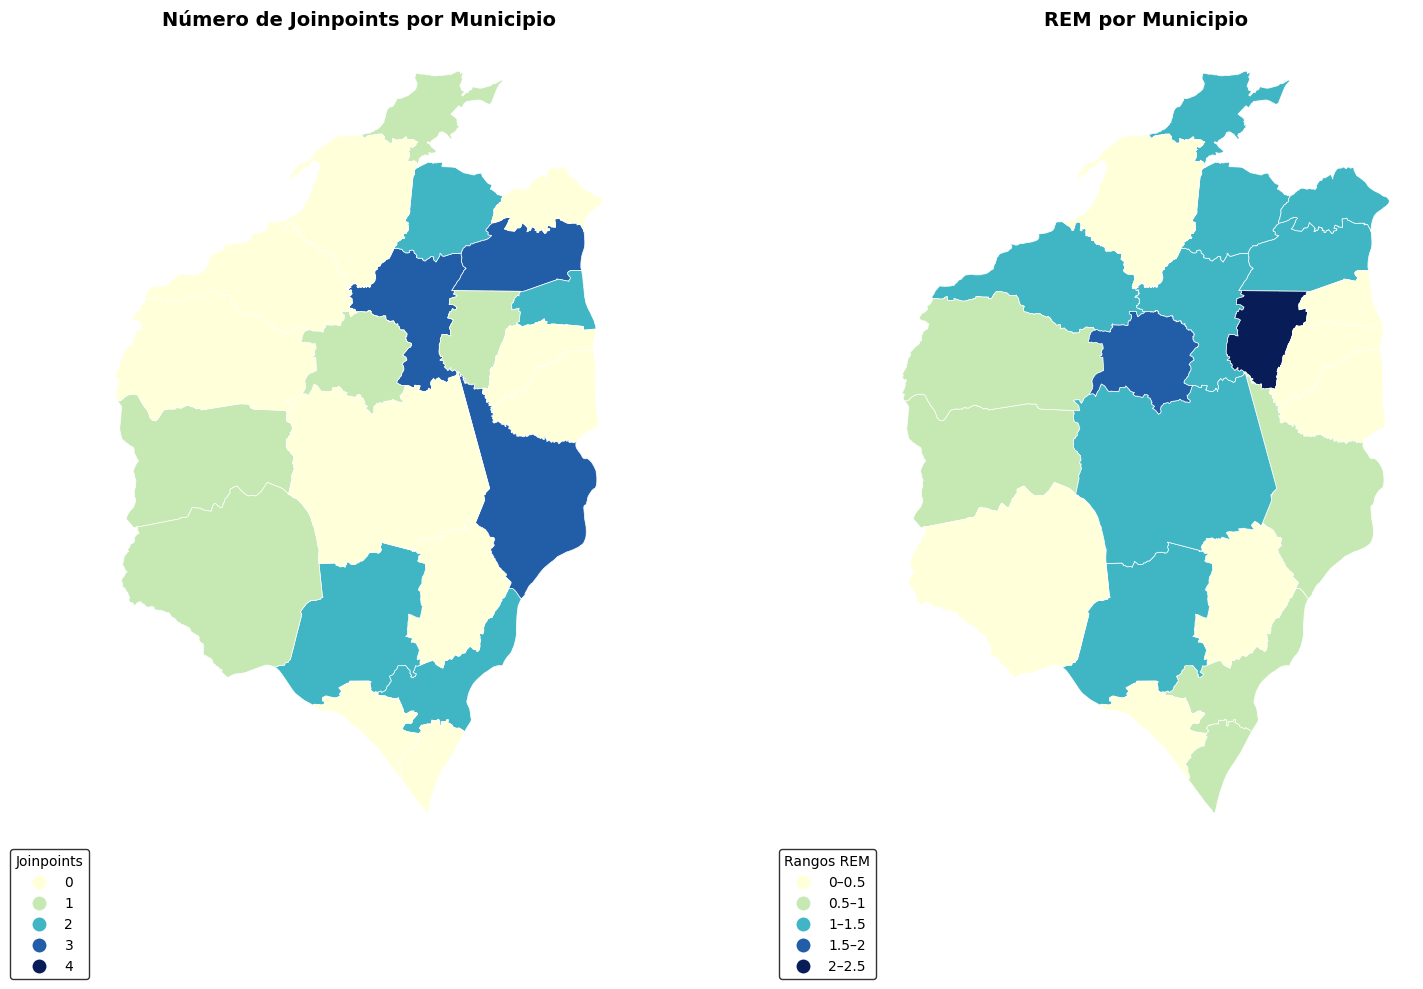

In [11]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# ============================
#  CARGAR SHAPEFILE
# ============================
mapa_atlantico = gpd.read_file(
    r'C:\Dengue_caracterization\MAPAS\MAPAS_MUN\MGN_ADM_MPIO_GRAFICO.shp',
    encoding="utf-8"
)

# Asegurar nombre uniforme
if "mpio_cnmbr" in mapa_atlantico.columns:
    mapa_atlantico = mapa_atlantico.rename(columns={'mpio_cnmbr': 'municipio'})

# Filtrar solo Atlántico
mapa_atlantico = mapa_atlantico[
    mapa_atlantico['dpto_cnmbr'].str.upper() == 'ATLÁNTICO'
]

# ============================
#  CARGAR DATOS TABULARES
# ============================
df_rem = pd.read_csv(r"C:\ETL_DENGUE\DATA\REM\REM_Total_Municipio.csv")
df_jp = pd.read_csv(r"C:\Dengue_caracterization\DATA_LAST\JoinPoint Results\Total.Export.Final.Selected.Model.txt")

# En df_jp, la columna con # joinpoints es: "Final Selected Model"
df_jp = df_jp[['municipio', 'Model']].drop_duplicates()
df_jp = df_jp.rename(columns={'Model': 'joinpoints'})

# Unir ambas bases al shapefile
mapa = mapa_atlantico.merge(df_jp, on="municipio", how="left")
mapa = mapa.merge(df_rem, on="municipio", how="left")

# ============================
#  BINNING PARA JOINPOINTS
# ============================
bins_jp = [0, 1, 2, 3, 4, 5]
labels_jp = ["0", "1", "2", "3", "4"]

mapa['jp_cat'] = pd.cut(
    mapa['joinpoints'],
    bins=bins_jp,
    labels=labels_jp,
    include_lowest=True
)

# ============================
#  BINNING PARA REM
# ============================
bins_rem = [0, 0.5, 1, 1.5, 2, 2.5]
labels_rem = [
    "0–0.5",
    "0.5–1",
    "1–1.5",
    "1.5–2",
    "2–2.5"
]

mapa['rem_cat'] = pd.cut(
    mapa['REM'],
    bins=bins_rem,
    labels=labels_rem,
    include_lowest=True
)

# ============================
#  CREAR FIGURA CON 2 MAPAS
# ============================
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# =======================================================
#  MAPA 1: JOINPOINTS
# =======================================================
mapa.plot(
    column='jp_cat',
    cmap='YlGnBu',
    linewidth=0.5,
    edgecolor='1',
    legend=True,
    ax=axes[0]
)

axes[0].set_title("Número de Joinpoints por Municipio",
                  fontsize=14, fontweight='bold')
axes[0].axis("off")

leg1 = axes[0].get_legend()
leg1.set_title("Joinpoints")
leg1.get_frame().set_facecolor("white")
leg1.get_frame().set_edgecolor("black")
leg1.set_bbox_to_anchor((0.01, 0.01))

# =======================================================
#  MAPA 2: REM
# =======================================================
mapa.plot(
    column='rem_cat',
    cmap='YlGnBu',
    linewidth=0.5,
    edgecolor='1',
    legend=True,
    ax=axes[1]
)

axes[1].set_title("REM por Municipio",
                  fontsize=14, fontweight='bold')
axes[1].axis("off")

leg2 = axes[1].get_legend()
leg2.set_title("Rangos REM")
leg2.get_frame().set_facecolor("white")
leg2.get_frame().set_edgecolor("black")
leg2.set_bbox_to_anchor((0.01, 0.01))

# Ajuste final
plt.tight_layout()
plt.show()


In [13]:
# Solo columnas municpio, joinpoint y rem
mdf = mapa[['municipio', 'joinpoints', 'REM']]

mdf

,municipio,joinpoints,REM
0,BARRANQUILLA,NaN,NaN
1,BARANOA,4.0,1.498139
2,CAMPO DE LA CRUZ,3.0,0.590871
3,CANDELARIA,0.0,0.295967
4,GALAPA,3.0,1.272247
5,JUAN DE ACOSTA,0.0,1.104327
6,LURUACO,2.0,0.890788
7,MALAMBO,4.0,1.197700
8,MANATÍ,3.0,1.167416
9,PALMAR DE VARELA,1.0,0.314548


C:\Users\TAWTOCA\AppData\Local\Temp\ipykernel_19628\1883174820.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_m["color"] = df_m["PPC Significant"].map({


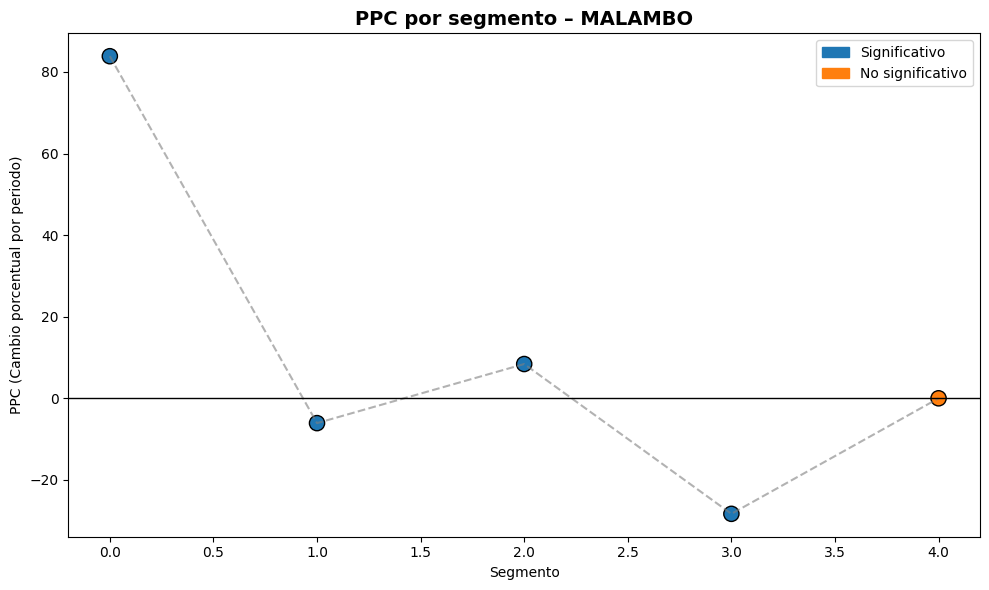

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================
# 1. Cargar datos
# ============================
df_ppc = pd.read_csv(r"C:\Dengue_caracterization\DATA_LAST\JoinPoint Results\Total.Export.APC.txt")

# ============================
# 2. Seleccionar municipio
# ============================
municipio = "MALAMBO"    # <-- cambiar aquí para analizar otro

df_m = df_ppc[df_ppc["municipio"] == municipio]

# ============================
# 3. Crear columna de color
# ============================
df_m["color"] = df_m["PPC Significant"].map({
    1: "tab:blue",       # significativo
    0: "tab:orange"      # no significativo
})

# ============================
# 4. Graficar
# ============================
plt.figure(figsize=(10,6))

plt.scatter(
    df_m["Segment"],
    df_m["PPC"],
    s=120,
    c=df_m["color"],
    edgecolor="black"
)

# Línea que une puntos
plt.plot(df_m["Segment"], df_m["PPC"], linestyle="--", color="gray", alpha=0.6)

# Líneas horizontales de referencia
plt.axhline(0, color="black", linewidth=1)

plt.title(f"PPC por segmento – {municipio}", fontsize=14, fontweight="bold")
plt.xlabel("Segmento")
plt.ylabel("PPC (Cambio porcentual por periodo)")

# Leyenda manual
import matplotlib.patches as mpatches
sig = mpatches.Patch(color="tab:blue", label="Significativo")
ns = mpatches.Patch(color="tab:orange", label="No significativo")
plt.legend(handles=[sig, ns], loc="upper right")

plt.tight_layout()
plt.show()
